In [2]:
# Importing Libraries: 

import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 
from meep import mpb
from scipy.optimize import minimize

%matplotlib inline 

In [3]:
def tapering(start: float, end: float, n:int):
    # Function that takes in the starting length and tapers quadratically to the ending length, with n total increments
    # start - starting length
    # end - ending length 
    # n - integer for specifying number of increments (for now restricted to being even)
    N = np.arange(1,n+1)
    tapered = start - (start-end)*(N/n)**2
    return tapered

In [4]:
taperr = tapering(380,188,6)
print(taperr)

[374.66666667 358.66666667 332.         294.66666667 246.66666667
 188.        ]


In [8]:
def tapered(width: float, length:float, xlength: float, ylengths: float):
    # width - width of our beam in nanometers
    # length - length of our beam in nanometers
    # ylengths - the array of vertical lengths tapered
    # xlength - length of our holes along the horizontal direction

    c = 3e8 # Speed of light for conversion later

    # Parameters for the computational cell: 
    pml_padding = length
    padding_to_pml = 4*length
    sx = 1*(len(ylengths))       # We will scale the dimensions of everything else by the length (for example we scaled the paddings above by the length)
    sy = 2*(pml_padding + padding_to_pml + width)/length  
    res = 64     # I had set the resolution to a power of two, I dont know if that will aid in the computational speed but Meep mentioned somewhere in the documentation to do this

    cell = mp.Vector3(sx,sy)

    # For the silicon we want to use and our approximate target wavelength is below: 
    eps_silicon = 12
    thickness = 220
    wavelength = 1540 

    # Defining our waveguide given the parameters, meep assumes periodic structure: 
    beam = mp.Block(size = (sx, width/length, thickness/length), material = mp.Medium(epsilon = eps_silicon) )
    holes = []
    for i in range(len(ylengths)): 
        holes.append(mp.Ellipsoid(center = mp.Vector3((-sx/2 + .5) + i, 0, 0), size = mp.Vector3(xlength, ylengths[i], thickness)/length, e1 = mp.Vector3(1,0,0), e2 = mp.Vector3(0,1,0), e3 = mp.Vector3(0,0,1),
                          material = mp.Medium(epsilon = 1)))

    geometry = [beam]+holes

    # Other things for simulation: It is to note that say we want to run for a certian number of periods, then we would divide our time by the frequency below
    fcenter = length/wavelength           # In meep units, the frequency is specified by 1/lambda according to https://meep.readthedocs.io/en/latest/Introduction/#units-in-meep
    df = .5*fcenter

    # Broad source to excite modes
    source = mp.Source(mp.GaussianSource(fcenter, fwidth = df), mp.Hz, mp.Vector3(0, 0))
    pml_layers = [mp.PML(pml_padding/length, direction =mp.Y)]

    simulation = mp.Simulation(
        cell_size = cell, 
        boundary_layers = pml_layers, 
        geometry = geometry, 
        sources = [source], 
        resolution = res
        )

    f = plt.figure(dpi=200)
    simulation.plot2D(ax = f.gca())
    f.gca().xaxis.set_visible(False)
    f.suptitle('Geometry of Simulation')
    plt.show()

     block, center = (0,0,0)
          size (6,1.48368,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     ellipsoid, center = (-2.5,0,0)
          size (0.646884,1.11177,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (-1.5,0,0)
          size (0.646884,1.06429,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (-0.5,0,0)
          size (0.646884,0.985163,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (0.5,0,0)
          size (0.646884,0.874382,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (1.5,0,0)
          size (0.646884,0.731949,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
     

          dielectric constant epsilon diagonal = (1,1,1)


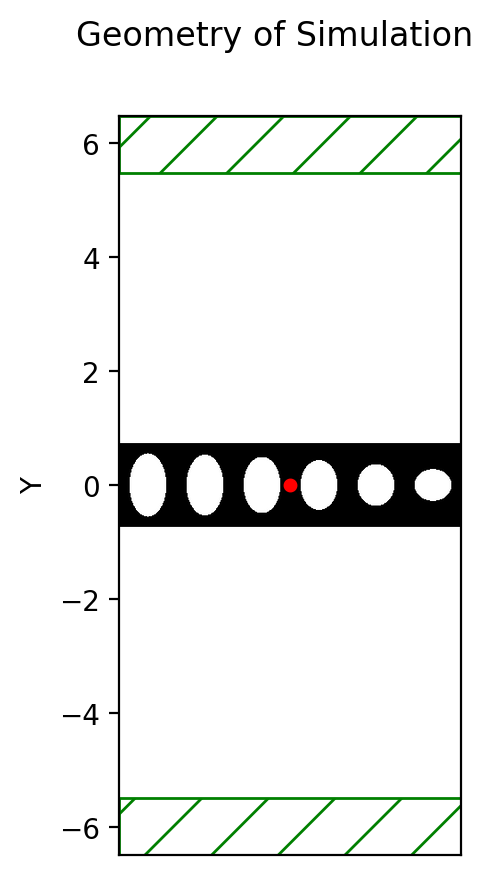

In [9]:
tapered(500, length = 337, xlength= 218, ylengths = taperr)